In [2]:
import numpy as np
import matplotlib.pyplot as plt   

## Understanding Data


In [3]:
headers = np.genfromtxt('../data/student_data.csv', delimiter=',', dtype=str, max_rows=1)
stu_performance_data = np.genfromtxt("../data/student_data.csv", delimiter=",", skip_header=1, dtype=str)
print(headers)
print(stu_performance_data.shape)
print(stu_performance_data.dtype)
print(stu_performance_data[0])

['school' 'sex' 'age' 'address' 'famsize' 'Pstatus' 'Medu' 'Fedu' 'Mjob'
 'Fjob' 'reason' 'guardian' 'traveltime' 'studytime' 'failures'
 'schoolsup' 'famsup' 'paid' 'activities' 'nursery' 'higher' 'internet'
 'romantic' 'famrel' 'freetime' 'goout' 'Dalc' 'Walc' 'health' 'absences'
 'G1' 'G2' 'G3']
(395, 33)
<U10
['GP' 'F' '18' 'U' 'GT3' 'A' '4' '4' 'at_home' 'teacher' 'course' 'mother'
 '2' '2' '0' 'yes' 'no' 'no' 'no' 'yes' 'yes' 'no' 'no' '4' '3' '4' '1'
 '1' '3' '6' '5' '6' '6']


## G3 - Grades of students


In [4]:
# Finding index of G3
G3_index = np.where(headers == 'G3')[0][0]
# print(G3_index) ---> 32

G3_col = stu_performance_data[:, 32].astype(int)
print(G3_col)

[ 6  6 10 15 10 15 11  6 19 15  9 12 14 11 16 14 14 10  5 10 15 15 16 12
  8  8 11 15 11 11 12 17 16 12 15  6 18 15 11 13 11 12 18 11  9  6 11 20
 14  7 13 13 10 11 13 10 15 15  9 16 11 11  9  9 10 15 12  6  8 16 15 10
  5 14 11 10 10 11 10  5 12 11  6 15 10  8  6 14 10  7  8 18  6 10 14 10
 15 10 14  8  5 17 14  6 18 11  8 18 13 16 19 10 13 19  9 16 14 13  8 13
 15 15 13 13  8 12 11  9  0 18  0  0 12 11  0  0  0  0 12 15  0  9 11 13
  0 11  0 11  0 10  0 14 10  0 12  8 13 10 15 12  0  7  0 10  7 12 10 16
  0 14  0 16 10  0  9  9 11  6  9 11  8 12 17  8 12 11 11 15  9 10 13  9
  8 10 14 15 16 10 18 10 16 10 10  6 11  9  7 13 10  7  8 13 14  8 10 15
  4  8  8 10  6  0 17 13 14  7 15 12  9 12 14 11  9 13  6 10 13 12 11  0
 12 12  0 12  0 18 13  8  5 15  8 10  8  8 12  8 13 11 14  0 18  8 12  9
  0 17 10 11 10  0  9 14 11 14 10 12  9  9  8 10  8 10 12 10 11 11 19 12
 14 15 11 15 13 18 14 11  0  8 14 16 11 10 14 18 13 12 18  8 12 10  0 13
 11 11 13 11  0  9 10 11 13  9 11 15 15 11 16 10  9

# Study Time Column


1 --> less than 2 hours/week
2 --> 2 to 5 hours/week
3 --> 5 to 10 hours/week
4 --> more than 10 hours/week
Mostly students study 2 to 5 hr/week

---------------------------------- 

Studytime 1: 10.05
Studytime 2: 10.17
Studytime 3: 11.40
Studytime 4: 11.26


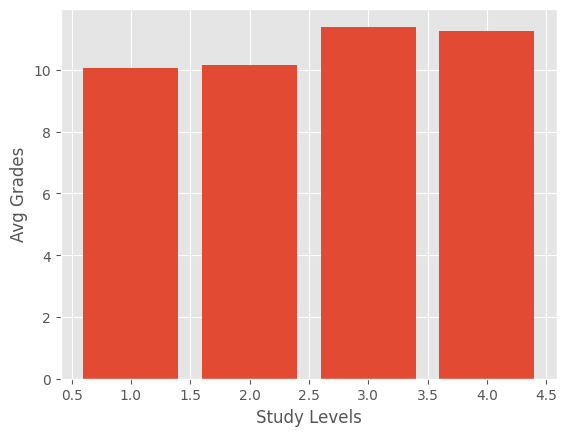

In [5]:
# Finding Index of studytime column
studytime_index = np.where(headers == 'studytime')[0][0]
# print(studytime_index) 

# Understading Studytime column
studytime_col = stu_performance_data[:, 13].astype(int)
values, counts = np.unique(studytime_col, return_index=False, return_inverse=False, return_counts=True)
print(f"{values[0]} --> less than 2 hours/week")
print(f"{values[1]} --> 2 to 5 hours/week")
print(f"{values[2]} --> 5 to 10 hours/week")
print(f"{values[3]} --> more than 10 hours/week")

# Maximum occurrence count
max_count = counts.max()

# Most frequent value(s)
most_frequent_values = values[counts == counts.max()]

if (most_frequent_values == 1):
    print(f"Mostly students study less than 2hr/week\n")
elif (most_frequent_values == 2):
    print(f"Mostly students study 2 to 5 hr/week\n")
elif (most_frequent_values == 3):
    print(f"Mostly students study 5 to 10 hr/week\n")
else:
    print(f"Mostly students study more than 10 hr/week\n")

print("---------------------------------- \n")

# How it effects G3
for level in [1,2,3,4]:
    avg = np.mean(G3_col[studytime_col == level])
    print(f'Studytime {level}: {avg:.2f}')  

study_levels = np.array([1,2,3,4])

avg_grades = np.array([
    np.mean(G3_col[studytime_col == 1]),
    np.mean(G3_col[studytime_col == 2]),
    np.mean(G3_col[studytime_col == 3]),
    np.mean(G3_col[studytime_col == 4])
])
plt.style.use('ggplot')
plt.bar(study_levels, avg_grades)
plt.xlabel("Study Levels")
plt.ylabel("Avg Grades")
plt.show()

# Failures Column

0 --> 312 
 1 --> 50 
 2 --> 17 
 3 --> 16
---------------------------------- 

Failures 0: 11.25
Failures 1: 8.12
Failures 2: 6.24
Failures 3: 5.69


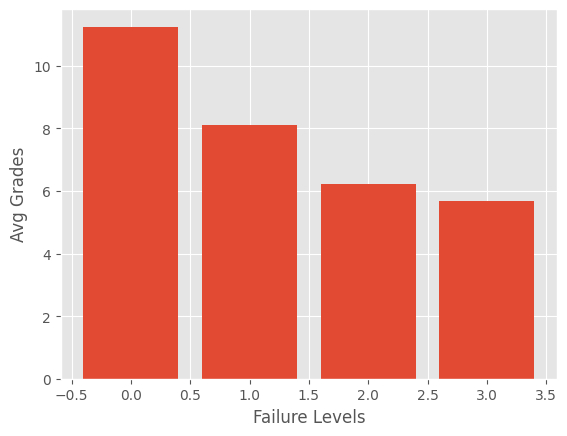

Std 0: 4.16
Std 1: 4.66
Std 2: 4.70
Std 3: 4.06


In [13]:
fail_index = np.where(headers == "failures")[0][0]
# print(fail_index) ---> Failures index is 14

fail_col = stu_performance_data[:, 14].astype(int)
values, counts = np.unique(fail_col, return_index=False, return_inverse=False, return_counts=True)
print(values[0],"-->",counts[0],"\n",
    values[1],"-->", counts[1],"\n",
    values[2],"-->", counts[2],"\n",
    values[3],"-->", counts[3])

print("---------------------------------- \n")

# How it effects G3
for level in [0, 1, 2 , 3]:
    avg = np.mean(G3_col[fail_col == level])
    print(f"Failures {level}: {avg:.2f}")

failure_level = np.array([0, 1, 2, 3])
avg_grades = np.array([
    np.mean(G3_col[fail_col == 0]),
    np.mean(G3_col[fail_col == 1]),
    np.mean(G3_col[fail_col == 2]),
    np.mean(G3_col[fail_col == 3])
])
plt.style.use('ggplot')

plt.bar(failure_level, avg_grades)
plt.xlabel("Failure Levels")
plt.ylabel("Avg Grades")
plt.show()

# Standard deviation
for level in [0, 1, 2, 3]:
    std = np.std(G3_col[fail_col == level])
    print(f"Std {level}: {std:.2f}")

# Sex Column

F ---> 208
M ---> 187
M: 10.91
F: 9.97


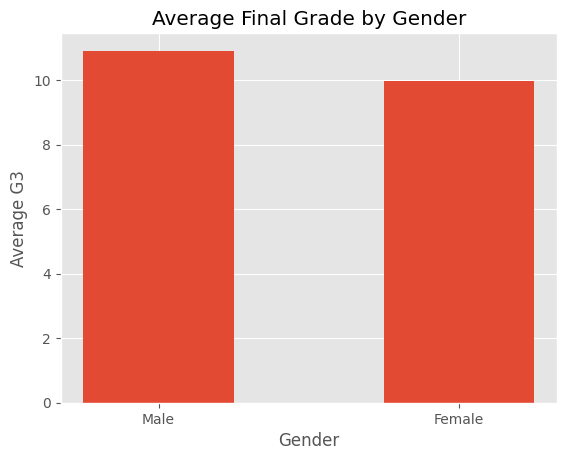

In [7]:
sex_col = stu_performance_data[:,1]
values, counts = np.unique(sex_col, return_index=False, return_inverse=False, return_counts=True)
for val, cnt in zip(values, counts):
    print(val, "--->", cnt)

# How it effects G3
for gender in ["M", "F"]:
    avg = np.mean(G3_col[sex_col == gender])
    print(f"{gender}: {avg:.2f}")

gender = ["Male", "Female"]
avg_grades = np.array([
    np.mean(G3_col[sex_col == "M"]),
    np.mean(G3_col[sex_col == "F"])
])

plt.bar(gender, avg_grades, width=0.5)   
plt.title("Average Final Grade by Gender")
plt.xlabel("Gender")
plt.ylabel("Average G3")

plt.show()

# Absences Column

0-5: 10.17
6-10: 11.40
11-15: 10.27
16-100: 10.03


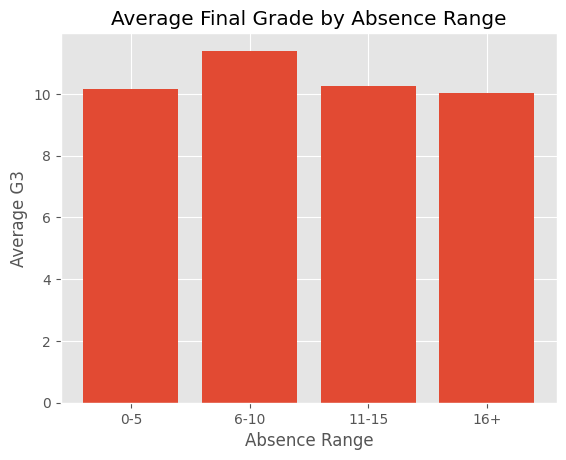

In [8]:
# Finding absences column index
absences_index = np.where(headers == "absences")[0][0]
# print(absences_index) ---> 29

absences_col = stu_performance_data[:,29].astype(int)
values, counts = np.unique(absences_col, return_index=False, return_inverse=False, return_counts=True)

ranges = [
    (0,5),
    (6,10),
    (11,15),
    (16,100)
]

for low, high in ranges:
    mask = (absences_col >= low) & (absences_col <= high)
    avg = np.mean(G3_col[mask])
    print(f"{low}-{high}: {avg:.2f}")

# Showing the effect of absence on grades by using bar graph
labels = ["0-5", "6-10", "11-15", "16+"]
avg_grades = [10.17, 11.40, 10.27, 10.03]

plt.bar(labels, avg_grades)

plt.title("Average Final Grade by Absence Range")
plt.xlabel("Absence Range")
plt.ylabel("Average G3")

plt.show()


# Go-out column

1 ---> 23
2 ---> 103
3 ---> 130
4 ---> 86
5 ---> 53

------------------------------

1: 9.87
2: 11.19
3: 10.96
4: 9.65
5: 9.04


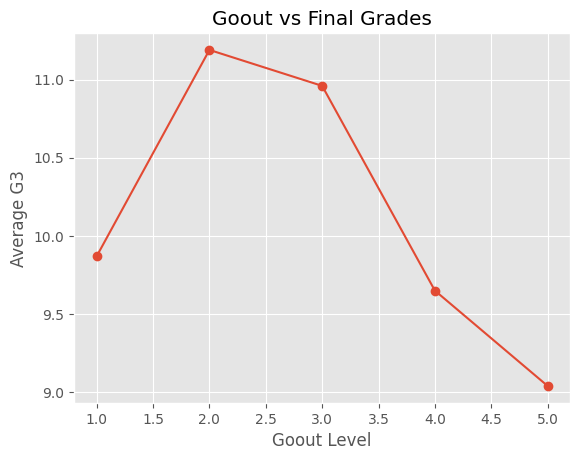

In [9]:
# Finding index of goout column
goout_index = np.where(headers == "goout")[0][0]
# print(goout_index) ---> 25

goout_col = stu_performance_data[:, 25].astype(int)
values, counts = np.unique(goout_col, return_counts=True, return_index=False, return_inverse=False)
for val, cnt in zip(values, counts):
    print(val, "--->", cnt)

print('\n------------------------------\n')

for goout_times in [1,2,3,4,5]:
    avg = np.mean(G3_col[goout_col == goout_times])
    print(f"{goout_times}: {avg:.2f}")

# Showing the effect of goout column on grades by using plot graph.
goout_level = [1,2,3,4,5]
avg_grades = [9.87, 11.19, 10.96, 9.65, 9.04]

plt.plot(goout_level, avg_grades, marker='o')
plt.grid(True)
plt.title("Goout vs Final Grades")
plt.xlabel("Goout Level") 
plt.ylabel("Average G3")
plt.show()

# Higher Education

In [16]:
# Finding Index of higher column 
higher_idx = np.where(headers == "higher")[0][0]
# print(higher_idx) ---> 20 

higher_col = stu_performance_data[:, 20]

for education in ["yes", "no"]:
    avg = np.mean(G3_col[higher_col == education])
    print(f"{education}: {avg:.2f}")

# Standard deviation
for education in ["yes", "no"]:
    std = np.std(G3_col[higher_col == education])
    print(f"Std of {education}: {std:.2f}")

yes: 10.61
no: 6.80
Std of yes: 4.49
Std of no: 4.71


# Internet Column

yes: 10.62
no: 9.41


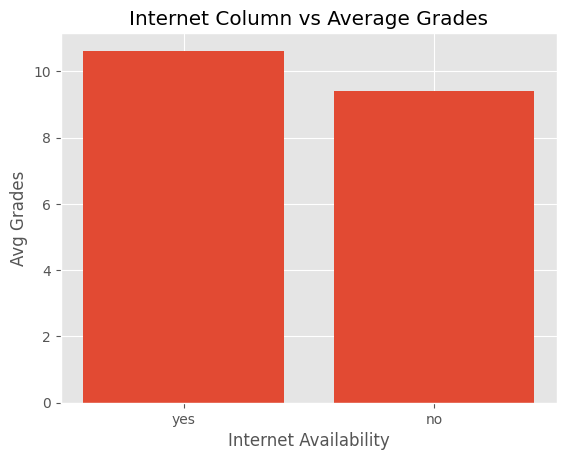

yes std: 4.57
no std: 4.45


In [11]:
internet_ind = np.where(headers == "internet")[0][0]
# internet_ind ---> 21

internet_col = stu_performance_data[:, 21]
values, counts = np.unique(internet_col, return_counts=True, return_index=False, return_inverse=False)
# print(values)
# print(counts)

for options in ["yes", "no"]:
    avg = np.mean(G3_col[internet_col == options])
    print(f"{options}: {avg:.2f}")

options = ["yes", "no"]
avg_grades = [10.62, 9.41]

plt.bar(options, avg_grades)

plt.title("Internet Column vs Average Grades")
plt.xlabel('Internet Availability')
plt.ylabel('Avg Grades')
plt.show()

# Standard Deviation
yes_std = np.std(G3_col[internet_col == "yes"])
no_std = np.std(G3_col[internet_col == "no"])

print(f"yes std:", round(yes_std, 2))
print(f"no std:", round(no_std, 2))



# Schoolsup Column

In [12]:
# Finding index of schoolsup column
sclsup_ind = np.where(headers == "schoolsup")[0][0]
# print(sclsup_ind) ---> 15

# Getting schoolsup column 
sclsup_col = stu_performance_data[:, 15]

# Seeing how it effect G3
for options in ["yes", "no"]:
    avg = np.mean(G3_col[sclsup_col == options])
    print(f"{options}: {avg:.2f}")



yes: 9.43
no: 10.56
